## Load Data

In [124]:
import pandas as pd

df = pd.read_csv("/content/CC GENERAL (1).csv")

df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


## Data Preprocessing

In [125]:
df = df.drop(columns=["CUST_ID"]).dropna(axis=1)

df.isnull().sum()

,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0
CASH_ADVANCE_FREQUENCY,0


## Prepare Data for Clustering

In [126]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test = train_test_split(
    df,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Elbow Method for K-Means

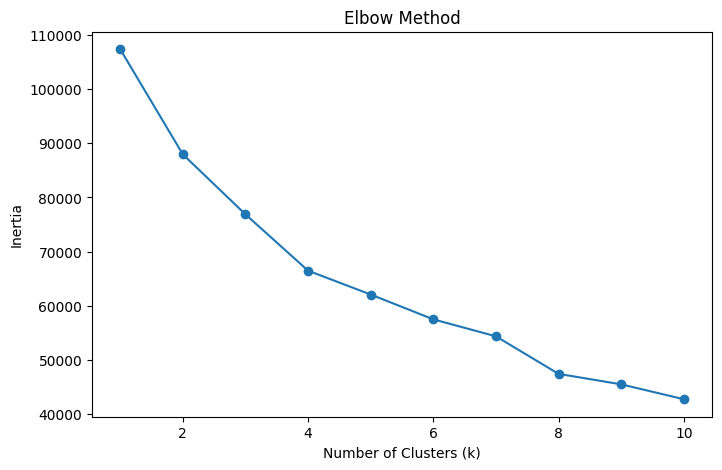

In [127]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1,11):
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X_train)
    inertia.append(model.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), inertia, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.show()

## Evaluate K-Means with Silhouette Score

In [128]:
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)

    kmeans.fit(X_train)

    predictions = kmeans.predict(X_test)

    score = silhouette_score(X_test, predictions)

    print(f"k = {k}, Silhouette Score = {score:.4f}")

k = 2, Silhouette Score = 0.2334
k = 3, Silhouette Score = 0.2231
k = 4, Silhouette Score = 0.2171
k = 5, Silhouette Score = 0.2163
k = 6, Silhouette Score = 0.2330
k = 7, Silhouette Score = 0.2138
k = 8, Silhouette Score = 0.2549
k = 9, Silhouette Score = 0.2536
k = 10, Silhouette Score = 0.2448


## Apply K-Means Clustering

In [129]:
best_k = 8

kmeans = KMeans(n_clusters=best_k, random_state=42)

kmeans.fit(X_train)

predictions = kmeans.predict(X_test)

## K-Means Cluster Distribution

In [130]:
pd.Series(predictions).value_counts().sort_index()

,count
0,142
1,572
2,242
3,391
4,6
5,231
6,85
7,121


## K-Means Predictions Head

In [131]:
results = pd.DataFrame(predictions, columns=["Cluster"])

results.head(20)

,Cluster
0,5
1,1
2,3
3,2
4,3
5,3
6,7
7,3
8,3
9,0


## K-Means Silhouette Distribution

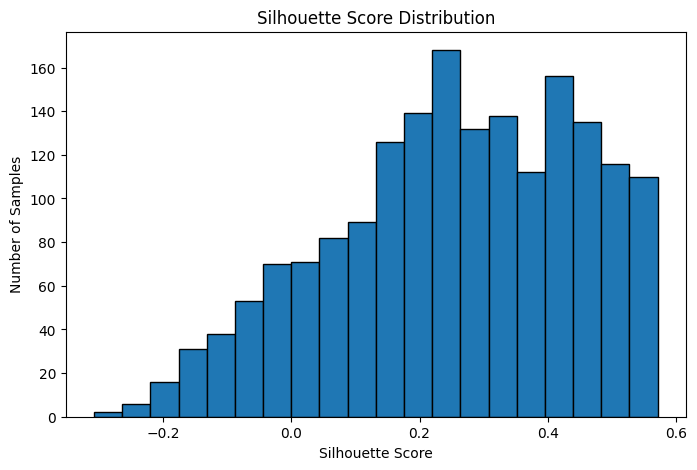

In [132]:
from sklearn.metrics import silhouette_samples
import matplotlib.pyplot as plt

sample_scores = silhouette_samples(X_test, predictions)

plt.figure(figsize=(8,5))
plt.hist(sample_scores, bins=20, edgecolor="black")
plt.title("Silhouette Score Distribution")
plt.xlabel("Silhouette Score")
plt.ylabel("Number of Samples")
plt.show()

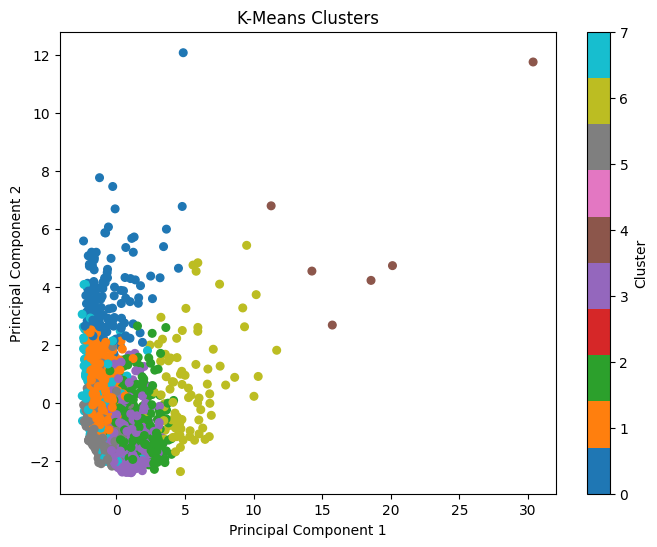

In [133]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_test)

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=predictions,
    cmap="tab10",
    s=30
)

plt.title("K-Means Clusters")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.colorbar(label="Cluster")
plt.show()

## DBSCAN Parameter Tuning

In [134]:
from sklearn.cluster import DBSCAN
from sklearn.model_selection import ParameterGrid

param_grid = {
    "eps": [0.5, 1.0, 1.5, 2.0, 2.5],
    "min_samples": [3, 5, 7, 10]
}

results = []

for params in ParameterGrid(param_grid):

    dbscan = DBSCAN(
        eps=params["eps"],
        min_samples=params["min_samples"]
    )

    labels = dbscan.fit_predict(X_train)

    mask = labels != -1

    if len(set(labels[mask])) > 1:
        score = silhouette_score(X_train[mask], labels[mask])

        results.append({
            "eps": params["eps"],
            "min_samples": params["min_samples"],
            "silhouette_score": score
        })

results = pd.DataFrame(results)
results.sort_values("silhouette_score", ascending=False).head(10)

,eps,min_samples,silhouette_score
13,2.5,5,0.572175
12,2.5,3,0.529315
11,2.0,7,0.440176
10,2.0,5,0.427130
9,2.0,3,0.366956
8,1.5,5,0.323544
6,1.0,7,0.028833
5,1.0,5,0.016304
7,1.5,3,0.007514
3,0.5,10,-0.158950


## Apply DBSCAN Clustering

In [135]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=2.5,
    min_samples=5
)

labels = dbscan.fit_predict(X_train)

## DBSCAN Cluster Distribution

In [136]:
pd.Series(labels).value_counts().sort_index()

,count
-1,198
0,6957
1,5


## DBSCAN Outlier Count

In [137]:
print("Number of Outliers:", (labels == -1).sum())

Number of Outliers: 198


## DBSCAN Predictions Head

In [138]:
results = pd.DataFrame({
    "Cluster": labels
})

results.head(20)

,Cluster
0,0
1,0
2,0
3,0
4,0
5,0
6,0
7,0
8,0
9,0


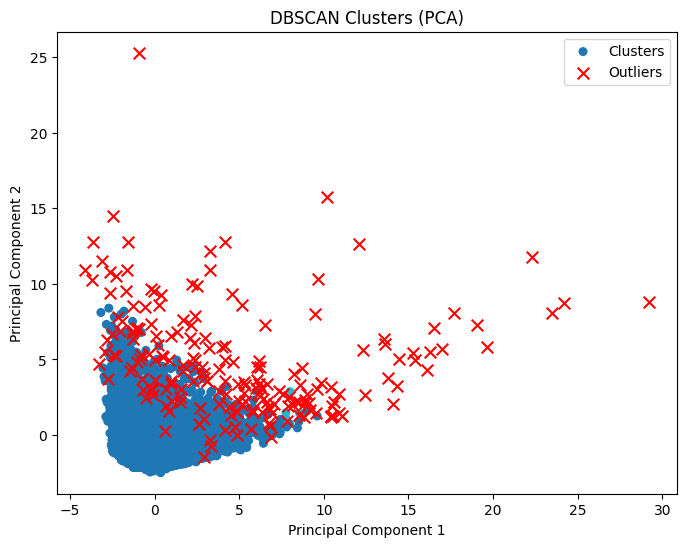

In [139]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reduce to 2 dimensions
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train)

plt.figure(figsize=(8,6))

# Plot clusters
plt.scatter(
    X_pca[labels != -1, 0],
    X_pca[labels != -1, 1],
    c=labels[labels != -1],
    cmap="tab10",
    s=30,
    label="Clusters"
)

# Plot outliers
plt.scatter(
    X_pca[labels == -1, 0],
    X_pca[labels == -1, 1],
    c="red",
    marker="x",
    s=70,
    label="Outliers"
)

plt.title("DBSCAN Clusters (PCA)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.show()